## stress testing the aral sea model

In [1]:
# setup imports
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))
import pandas as pd
import xarray as xr

import src.aral as aral

In [2]:
# Create a daily date range
dates = pd.date_range(start="1950-01-01", end="2020-12-31", freq="D")

# Create a DataFrame filled with zeros
# Example: columns for multiple stations or variables
columns = ["Syr Darya", "Amu Darya"]  # replace with your desired column names
df_zeros = pd.DataFrame(1000, index=dates, columns=columns)

df_zeros.index.name = "Time"
print(df_zeros.head())
print(df_zeros.tail())

            Syr Darya  Amu Darya
Time                            
1950-01-01       1000       1000
1950-01-02       1000       1000
1950-01-03       1000       1000
1950-01-04       1000       1000
1950-01-05       1000       1000
            Syr Darya  Amu Darya
Time                            
2020-12-27       1000       1000
2020-12-28       1000       1000
2020-12-29       1000       1000
2020-12-30       1000       1000
2020-12-31       1000       1000


In [3]:
AmuDarya = aral.River(df_zeros, q_col="Amu Darya")
SyrDarya = aral.River(df_zeros, q_col="Syr Darya")

In [4]:
aral_meteo = xr.open_dataset(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/AralSea/1940-2020/work/diagnostic/script/Derived_Makkink_evspsblpot.nc"
)
aral_precip = xr.open_dataset(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/AralSea/1940-2020/work/diagnostic/script/OBS6_ERA5_reanaly_1_day_pr_1940-2020.nc"
)
# Initial settings
initial_volume = 1060
ahv_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/ahv_curve.csv"

# Run the model
df_aral = aral.run_connected_aral_model(
    aral_meteo,
    rivers=[AmuDarya, SyrDarya],
    ahv_csv=ahv_file,
    V0_km3=initial_volume,
    start_time="1950-01-01",
    end_time="2020-12-31",
    tqdm_position=1,
    aral_precip=aral_precip,
)

Simulating Aral Sea volume balance:   0%|          | 0/25932 [00:00<?, ?it/s]

Found 4 NetCDF files in /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/dahiti


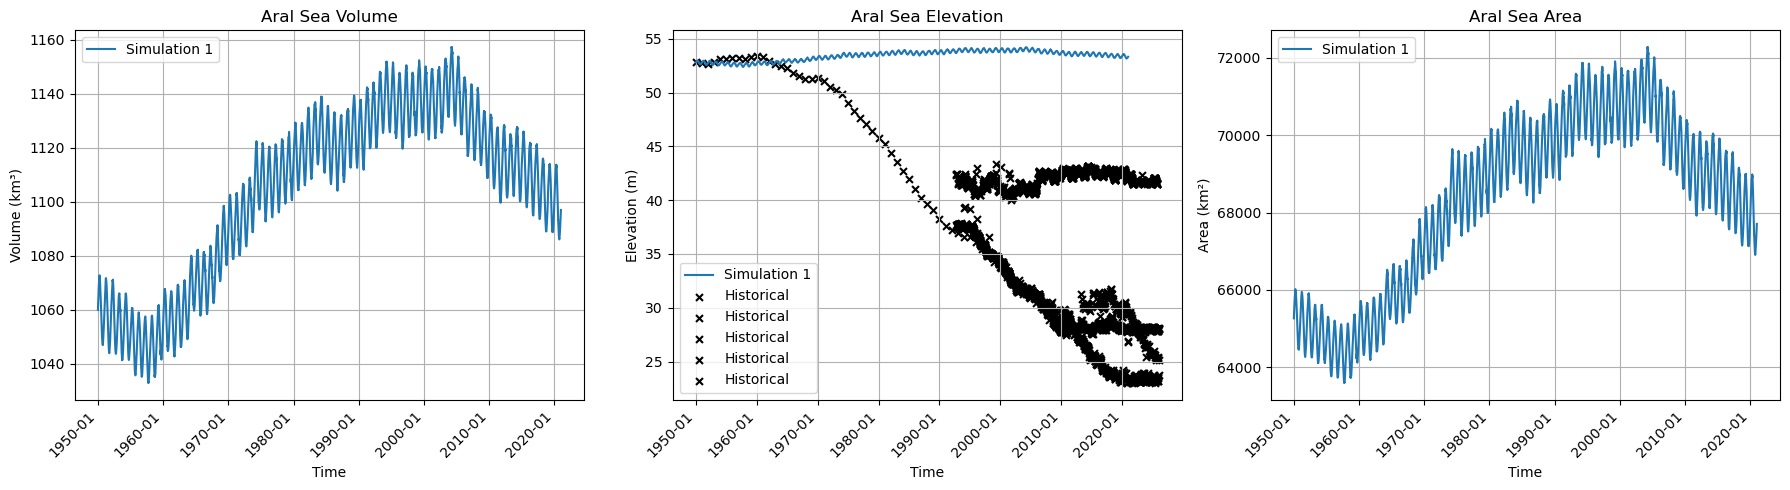

In [5]:
observation = aral.make_obs()
aral.plot_aral_results(df_aral, observations=observation)

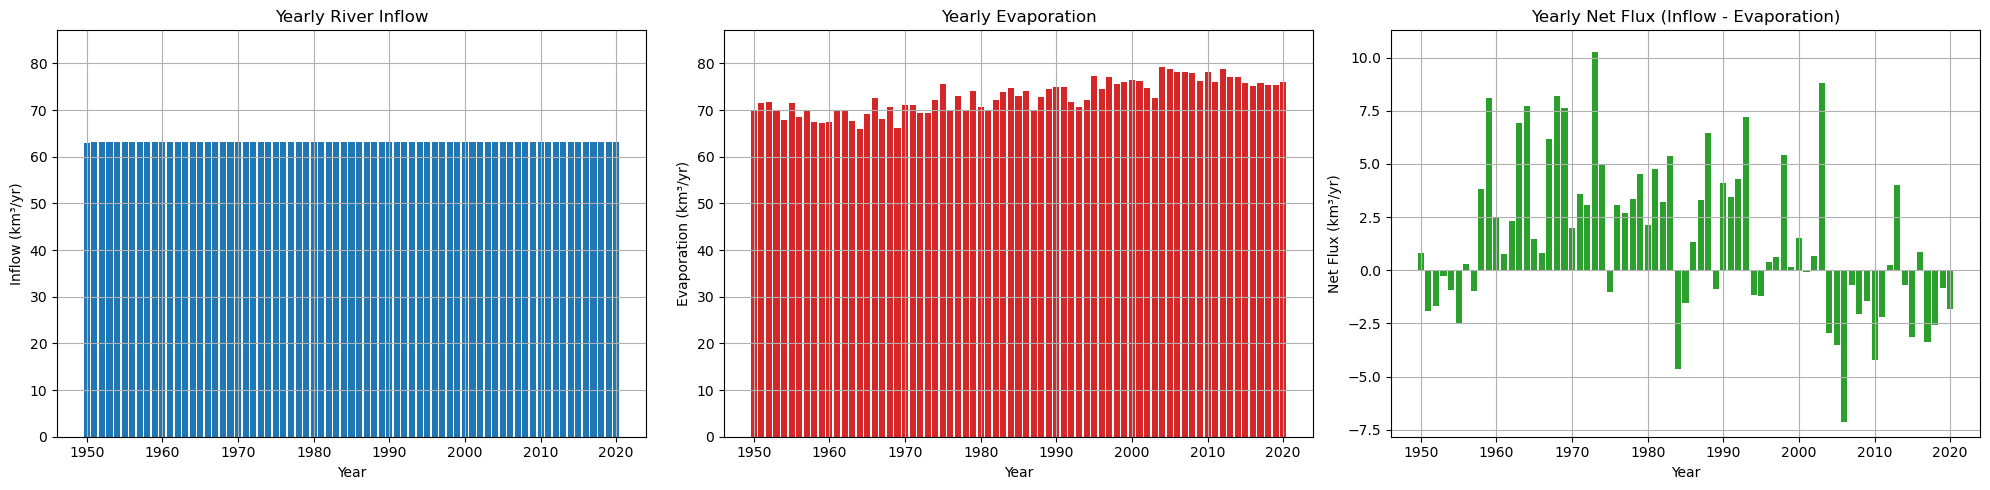

In [6]:
aral.plot_aral_fluxes(df_aral)

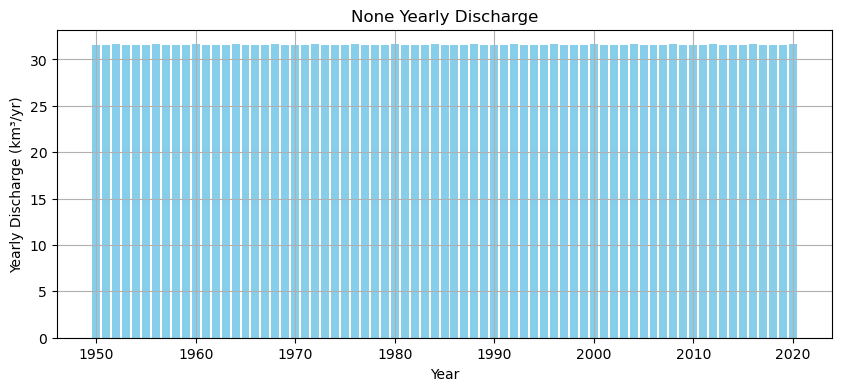

In [7]:
AmuDarya.plot_yearly()